# Pulse Radar Target Detection and Range Estimation
This notebook simulates a basic pulse radar system for detecting
multiple targets and estimating their ranges using cross-correlation.

In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import find_peaks

In [2]:
# ── Time axis ──────────────────────────────────────
t = np.linspace(0, 0.001, 1000)
dt = t[1] - t[0]

##  Generate Transmitted Pulse


In [3]:
tx_signal = np.zeros(len(t))
tx_signal[0:30] = 1  

In [4]:
delays = [80, 250, 500]   

##  Simulate Multiple Target Echoes

In [5]:
echo = np.zeros(len(t))           # start with empty echo buffer
for d in delays:
    echo += np.roll(tx_signal, d)

##  Add Gaussian Noise

In [6]:
noise = np.random.normal(0, 0.05, len(t))
received_signal = echo + noise

##  Visualize Transmitted and Received Signals

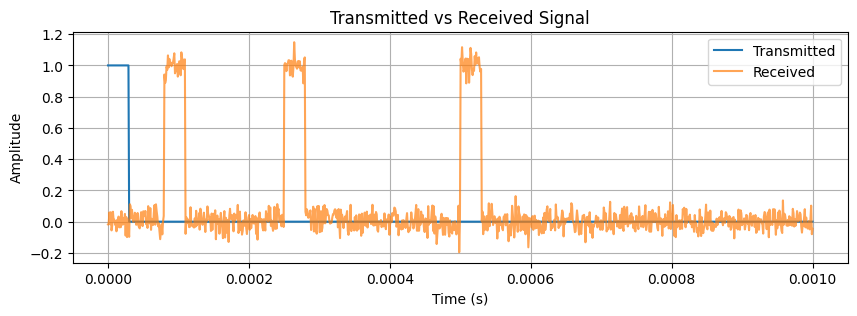

In [7]:
plt.figure(figsize=(10, 3))
plt.plot(t, tx_signal, label="Transmitted")
plt.plot(t, received_signal, label="Received", alpha=0.7)
plt.legend()
plt.title("Transmitted vs Received Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

##  Cross-Correlation

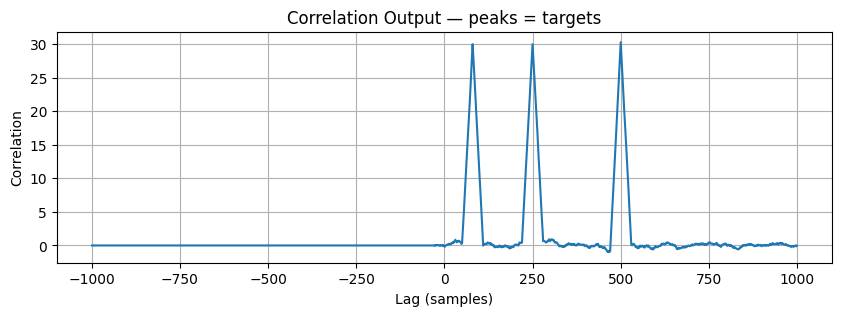

In [8]:
corr = signal.correlate(received_signal, tx_signal, mode='full')
lags = np.arange(-len(tx_signal) + 1, len(tx_signal))

plt.figure(figsize=(10, 3))
plt.plot(lags, corr)
plt.title("Correlation Output — peaks = targets")
plt.xlabel("Lag (samples)")
plt.ylabel("Correlation")
plt.grid(True)
plt.show()


##  Peak Detection and Range Estimation

In [9]:
peaks, _ = find_peaks(corr, prominence=np.max(corr) * 0.3, distance=50)

c = 3e8
print("Detected targets:")
for p in peaks:
    lag = lags[p]
    if lag <= 0:
        continue
    distance = (c * lag * dt) / 2
    print(f"Range = {distance:.0f} m")


Detected targets:
Range = 12012 m
Range = 37538 m
Range = 75075 m


## Results

The simulation successfully demonstrates the detection of multiple
target echoes and estimates their corresponding ranges using
correlation-based delay estimation.